## Research convention: entry timing and recorded exit prices

Trades enter at the close of the candle that produces the RSI crossing signal. Barrier monitoring begins with the following candle and uses closing prices only.

If the profit-taking barrier is **$102**, and the first candle whose close reaches or crosses it closes at **$103**, the recorded exit is **$103**. We do not substitute $102 as the execution price.

If a candle's high reaches $102 but its close is $101, the current implementation **does not register a barrier hit**. A time-barrier exit similarly records the selected candle's closing price. These are the conventions used for this research study.

The indicator matrix includes both the entry and exit candles. However, the return ending on the entry candle occurred before entry and is excluded from the trade's return attribution. Attributed holding-period returns begin with the return ending on the following candle and include the return ending on the exit candle.

### Study reminder: weighting mechanisms

I need to brush up on my understanding of return attribution, time decay, and class balancing. Investigate whether to normalize all combined weights together, what changing their overall scale does theoretically to model fitting and regularization, and how class balancing interacts with return and time weights.

Agreed weighting requirements: use `msft_events_clean`; default time-decay parameter `c=0.5`; use balanced class factors (`class_weight="balanced"` terminology); assign zero return weight to zero attributed returns and raise an error if all attributed returns are zero; provide an event-indexed diagnostic table. Include a `normalize_final` argument to toggle normalization of the combined return, time, and class weights to average 1. Default it to `False`, following the supplied excerpts, which normalize return weights before applying decay but do not show a final combined normalization. Apply class factors once when supplying combined sample weights to the model.


# Part 1: Data Analysis

The goal of this notebook is to practice the techniques introduced in **Part 1: Data Analysis** of *Advances in Financial Machine Learning* by Marcos López de Prado. Through Python implementations and experiments with financial data, I aim to understand how these methods prepare data for financial machine learning.

The notebook is organized into four sections:

1. **Financial Data Structures** — Explore how financial observations are organized, sampled, and transformed into useful datasets.
2. **Labeling** — Practice assigning targets to financial observations, including the triple-barrier method and meta-labeling.
3. **Sample Weights** — Explore how overlapping observations, sample uniqueness, and time decay affect the weight assigned to each training example.
4. **Fractionally Differentiated Features** — Practice fractional differentiation to balance stationarity with the preservation of information from past observations.

Each section will combine explanations, code, and observations from the results to build a practical understanding of the techniques.


## Study Signal: Wilder's 14-Period RSI

We will use **Wilder's 14-period Relative Strength Index (RSI)** to define entry signals, first for **MSFT**, then for each stock in the small-, medium-, and large-cap baskets. A period is one price bar: 14 hourly bars with `interval="1H"` or 14 daily bars with `interval="1D"`.

### RSI calculation

For closing price $P_t$, define the price change, gain, and nonnegative loss:

$$
\Delta P_t=P_t-P_{t-1},\qquad
G_t=\max(\Delta P_t,0),\qquad
L_t=\max(-\Delta P_t,0).
$$

Initialize the averages with the first 14 price changes (requiring 15 closing prices):

$$
\overline{G}_{14}=\frac{1}{14}\sum_{i=1}^{14}G_i,
\qquad
\overline{L}_{14}=\frac{1}{14}\sum_{i=1}^{14}L_i.
$$

For subsequent bars, apply Wilder's recursive smoothing:

$$
\overline{G}_t=\frac{13\overline{G}_{t-1}+G_t}{14},
\qquad
\overline{L}_t=\frac{13\overline{L}_{t-1}+L_t}{14}.
$$

Relative strength and RSI are then:

$$
RS_t=\frac{\overline{G}_t}{\overline{L}_t},
\qquad
RSI_t=100-\frac{100}{1+RS_t}.
$$

If average loss is zero and average gain is positive, RSI is 100; if average gain is zero and average loss is positive, RSI is 0. For this study, we will assign RSI = 50 when both averages are zero. RSI remains unavailable until the initial 14 price changes exist.

### Entry rules

We interpret crossing oversold as entering below 30, and crossing overbought as entering above 70:

$$
s_t=
\begin{cases}
+1 & \text{if } RSI_{t-1}\geq30\text{ and }RSI_t<30\quad\text{(long entry)},\\
-1 & \text{if } RSI_{t-1}\leq70\text{ and }RSI_t>70\quad\text{(short entry)},\\
0 & \text{otherwise (no new entry)}.
\end{cases}
$$

The signal is an entry event rather than a continuously held position. Staying beyond a threshold does not generate another entry. Evaluate crossings only when both RSI values are available, and act after bar $t$ closes. Holding periods and exits will be specified in the labeling study.

**Reference:** [RSI calculation and Wilder smoothing — StockCharts ChartSchool](https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi).


Loaded 3,478 hourly bars
Available range: 2024-10-07 09:30:00-04:00 to 2026-10-06 15:30:00-04:00


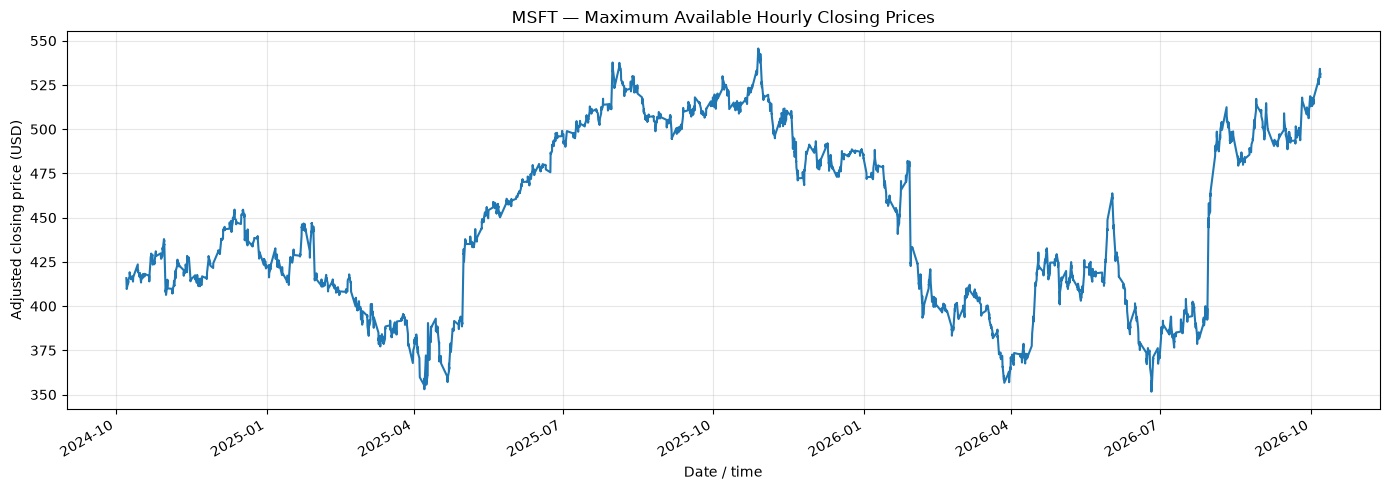

In [12]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

# Request the maximum hourly history Yahoo Finance makes available.
# Hourly history is limited to roughly the most recent 730 days.
msft_hourly = yf.Ticker("MSFT").history(
    period="max",
    interval="1h",
    auto_adjust=True,
)
if msft_hourly.empty:
    raise ValueError("Yahoo Finance returned no hourly MSFT data.")

msft_hourly = msft_hourly.sort_index()
msft_prices = msft_hourly[["Close"]].rename(columns={"Close": "MSFT"})
print(f"Loaded {len(msft_prices):,} hourly bars")
print(f"Available range: {msft_prices.index.min()} to {msft_prices.index.max()}")

ax = msft_prices.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Maximum Available Hourly Closing Prices",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Adjusted closing price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


,MSFT
Datetime,
2024-10-07 10:30:00-04:00,-0.108223
2024-10-07 11:30:00-04:00,-0.227510
2024-10-07 12:30:00-04:00,-0.256983
2024-10-07 13:30:00-04:00,-0.234655
2024-10-07 14:30:00-04:00,-0.529260


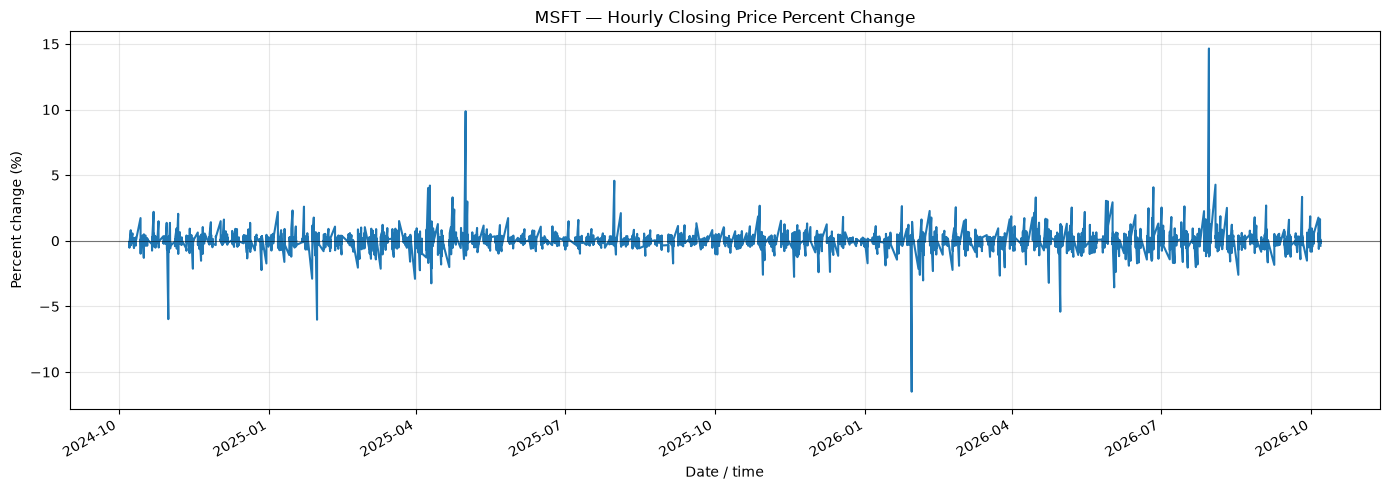

In [13]:
# Percent change between consecutive observed hourly closing prices.
# Drop the first bar, which has no previous price to compare against.
msft_pct_change = msft_prices.pct_change(fill_method=None).dropna() * 100
display(msft_pct_change.head())

ax = msft_pct_change.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Hourly Closing Price Percent Change",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Percent change (%)")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


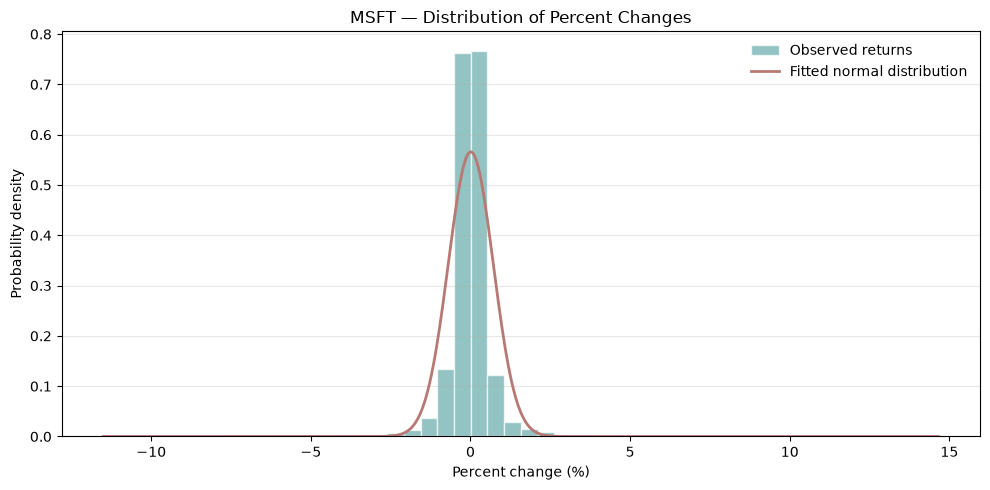

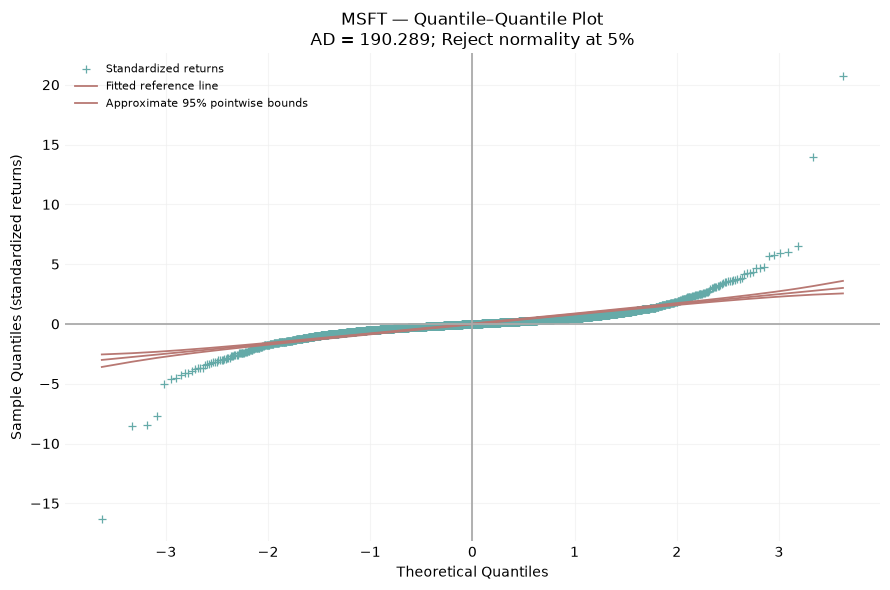

,n_obs,statistic,significance_level,critical_value,p_value,reject_normality,status
ticker,,,,,,,
MSFT,3477,190.28932,5.0,NaN,0.01,True,ok


In [14]:
from pathlib import Path
import sys

project_root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "HelperFunctions" / "sci_functions.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Cannot locate HelperFunctions/sci_functions.py.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HelperFunctions.sci_functions import return_normality

# Accepts multiple ticker columns; use input_type="prices" for price data.
msft_normality = return_normality(
    msft_pct_change,
    input_type="pct_change",
    plot_qq=True,
    plot_distribution=True,
    significance_level=5.0,
)
display(msft_normality)


## RSI Entry Signals

Calculate RSI from the same closing prices used for labeling. Buy signals mark crossings below 30; sell signals mark crossings above 70 when `allow_short=True`. Set `allow_short=False` for long-only entries. Warm-up bars generate no signals.


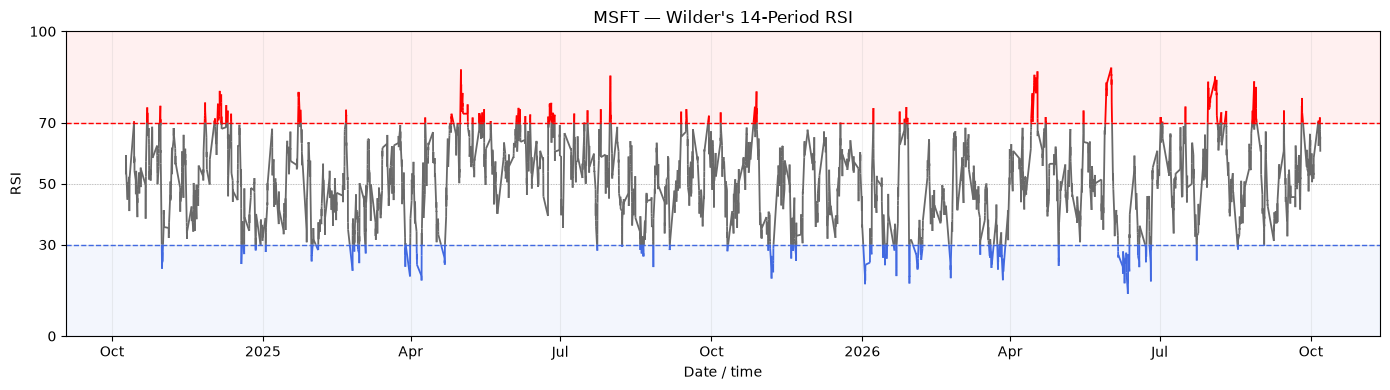

Total signals: 144
Buy signals (long entries): 65
Sell signals (short entries): 79


In [15]:
from HelperFunctions.signals import wilder_rsi

# Set False for long-only entries; rerun this and downstream cells after changing.
allow_short = True

msft_rsi = wilder_rsi(msft_prices, periods=14, plot=True)
previous_rsi = msft_rsi.shift(1)
valid_rsi = msft_rsi.notna() & previous_rsi.notna()
buy_signals = valid_rsi & (previous_rsi >= 30) & (msft_rsi < 30)
sell_signals = valid_rsi & (previous_rsi <= 70) & (msft_rsi > 70) & allow_short

buy_count = int(buy_signals.to_numpy().sum())
sell_count = int(sell_signals.to_numpy().sum())
print(f"Total signals: {buy_count + sell_count:,}")
print(f"Buy signals (long entries): {buy_count:,}")
print(f"Sell signals (short entries): {sell_count:,}")


## Triple-Barrier Meta-Labels

**Reference:** Marcos López de Prado (2018), *Advances in Financial Machine Learning*, Part 1, Chapter 3, **Labeling**: §3.3 **Computing Dynamic Thresholds**, §3.4 **The Triple-Barrier Method**, and §§3.6–3.7 **Meta-Labeling** and **How to Use Meta-Labeling**. Relevant implementation examples are Snippet 3.1 (volatility), Snippet 3.4 (vertical barriers), and Snippets 3.6–3.7 (events and binary meta-labels).

Our study adapts the framework to consecutive-bar volatility and close-only monitoring. Every RSI crossing is an independent event, including overlapping trades. The RSI rule supplies the side $s_i\in\{+1,-1\}$; the labeling algorithm determines the historical outcome. It does not train a model.

### Volatility target

For closing price $P_t$, consecutive-bar simple returns are:

$$
r_t=\frac{P_t}{P_{t-1}}-1,
\qquad
\alpha=\frac{2}{S+1},
$$

where $S$ is the configurable EWMA span in bars. For the valid returns available through $t$, normalized exponential weights and their weighted mean are:

$$
w_{t,k}=\frac{(1-\alpha)^{t-k}}{\sum_{j=1}^{t}(1-\alpha)^{t-j}},
\qquad
\mu_t=\sum_{k=1}^{t}w_{t,k}r_k.
$$

The bias-corrected weighted standard deviation used by `ewm(adjust=True).std(bias=False)` is:

$$
\sigma_t=
\sqrt{\frac{\sum_{k=1}^{t}w_{t,k}(r_k-\mu_t)^2}
{1-\sum_{k=1}^{t}w_{t,k}^2}}.
$$

The volatility frequency follows the data, with no annualization: hourly bars produce hourly-return volatility. For event $i$, freeze $\sigma_i=\sigma_{t_i}$ at its signal-close entry time $t_i$. Warm-up and minimum-target filters can exclude events with unavailable or insufficient volatility.

### Horizontal and vertical barriers

Enter at $P_{t_i}$ and monitor only subsequent closing prices. The side-adjusted return is:

$$
R_i(t)=s_i\left(\frac{P_t}{P_{t_i}}-1\right),\qquad t>t_i.
$$

With independent positive multipliers $m_{\mathrm{PT}}$ and $m_{\mathrm{SL}}$, the first horizontal touches are:

$$
\tau_i^{\mathrm{PT}}=\inf\{t>t_i:R_i(t)\geq m_{\mathrm{PT}}\sigma_i\},
$$

$$
\tau_i^{\mathrm{SL}}=\inf\{t>t_i:R_i(t)\leq -m_{\mathrm{SL}}\sigma_i\}.
$$

Equivalently, their price levels are:

$$
P_i^{\mathrm{PT}}=P_{t_i}(1+s_i m_{\mathrm{PT}}\sigma_i),
\qquad
P_i^{\mathrm{SL}}=P_{t_i}(1-s_i m_{\mathrm{SL}}\sigma_i).
$$

For a configurable holding limit of $D$ calendar days, use the first observed close at or after the elapsed-time deadline:

$$
\tau_i^{\mathrm{V}}=\inf\{t\in\mathcal{T}:t\geq t_i+D\text{ days}\},
\qquad
t_{1,i}=\min(\tau_i^{\mathrm{PT}},\tau_i^{\mathrm{SL}},\tau_i^{\mathrm{V}}),
$$

where $\mathcal{T}$ contains the observed bar timestamps. An untouched or unavailable barrier has no finite touch time. A horizontal touch on the vertical-exit close takes precedence when recording the exit reason. Exits use the observed closing price, which may overshoot the theoretical barrier.

### Binary meta-labels

For a completed event, realized return and label are:

$$
\mathrm{ret}_i=s_i\left(\frac{P_{t_{1,i}}}{P_{t_i}}-1\right),
\qquad
y_i=\mathbf{1}\{\mathrm{ret}_i>0\}.
$$

Profit-taking exits receive **1**; stop-loss exits receive **0**. Time exits receive **1** when profitable and **0** when losing or flat. Returns ignore trading costs. If the dataset ends before the vertical exit and no horizontal barrier was touched, the event remains **incomplete** and receives no label. Preserve all event IDs and entry/exit timestamps for the subsequent overlap analysis.


In [16]:
import pandas as pd
from HelperFunctions.labeling import estimate_volatility, create_events, get_labels

# Adjustable study parameters. Span and warm-up are measured in data bars.
volatility_span = 100
volatility_min_periods = 2
profit_taking_multiplier = 1.0
stop_loss_multiplier = 1.0
max_holding_days = 7
min_target_return = 0.0

# All crossings are independent entries, including overlapping trades.
trade_sides = buy_signals.astype(int) - sell_signals.astype(int)
msft_volatility = estimate_volatility(
    msft_prices, span=volatility_span, min_periods=volatility_min_periods
)
msft_events = create_events(
    msft_prices,
    trade_sides,
    volatility=msft_volatility,
    pt_mult=profit_taking_multiplier,
    sl_mult=stop_loss_multiplier,
    holding_days=max_holding_days,
    min_ret=min_target_return,
)
msft_labels = get_labels(msft_events)

print(f"Total signal events: {len(msft_events):,}")
print("Event status counts:")
print(msft_events["status"].value_counts().to_string())
print("\nCompleted exit counts:")
print(msft_labels["exit_type"].value_counts().to_string())
print(f"\nProfitable labels (1): {int(msft_labels['bin'].eq(1).sum()):,}")
print(f"Unprofitable/flat labels (0): {int(msft_labels['bin'].eq(0).sum()):,}")
display(msft_events.head())
display(msft_labels.head())


Total signal events: 144
Event status counts:
status
complete    144

Completed exit counts:
exit_type
stop_loss        72
profit_taking    70
time              2

Profitable labels (1): 72
Unprofitable/flat labels (0): 72


,ticker,signal_time,entry_time,entry_price,side,trgt,pt_mult,sl_mult,pt_return,sl_return,...,sl_price,deadline,vertical_time,status,exclusion_reason,pt_time,sl_time,t1,exit_type,exit_price
event_id,,,,,,,,,,,,,,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-14 09:30:00-04:00,423.595001,-1,0.004395,1.0,1.0,0.004395,-0.004395,...,425.456863,2024-10-21 09:30:00-04:00,2024-10-21 09:30:00-04:00,complete,None,2024-10-14 10:30:00-04:00,NaT,2024-10-14 10:30:00-04:00,profit_taking,419.429993
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-22 09:30:00-04:00,428.070007,-1,0.005051,1.0,1.0,0.005051,-0.005051,...,430.232308,2024-10-29 09:30:00-04:00,2024-10-29 09:30:00-04:00,complete,None,2024-10-23 12:30:00-04:00,NaT,2024-10-23 12:30:00-04:00,profit_taking,425.139404
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 12:30:00-04:00,427.350006,-1,0.004947,1.0,1.0,0.004947,-0.004947,...,429.464109,2024-10-29 12:30:00-04:00,2024-10-29 12:30:00-04:00,complete,None,NaT,2024-10-22 13:30:00-04:00,2024-10-22 13:30:00-04:00,stop_loss,429.695007
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-30 09:30:00-04:00,437.869995,-1,0.004478,1.0,1.0,0.004478,-0.004478,...,439.830866,2024-11-06 08:30:00-05:00,2024-11-06 09:30:00-05:00,complete,None,2024-10-30 13:30:00-04:00,NaT,2024-10-30 13:30:00-04:00,profit_taking,434.529999
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-30 12:30:00-04:00,437.424988,-1,0.004373,1.0,1.0,0.004373,-0.004373,...,439.337967,2024-11-06 11:30:00-05:00,2024-11-06 11:30:00-05:00,complete,None,2024-10-30 13:30:00-04:00,NaT,2024-10-30 13:30:00-04:00,profit_taking,434.529999


,ticker,entry_time,t1,side,exit_type,raw_return,ret,bin
event_id,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-14 10:30:00-04:00,-1,profit_taking,-0.009833,0.009833,1
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-23 12:30:00-04:00,-1,profit_taking,-0.006846,0.006846,1
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 13:30:00-04:00,-1,stop_loss,0.005487,-0.005487,0
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-30 13:30:00-04:00,-1,profit_taking,-0.007628,0.007628,1
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-30 13:30:00-04:00,-1,profit_taking,-0.006618,0.006618,1


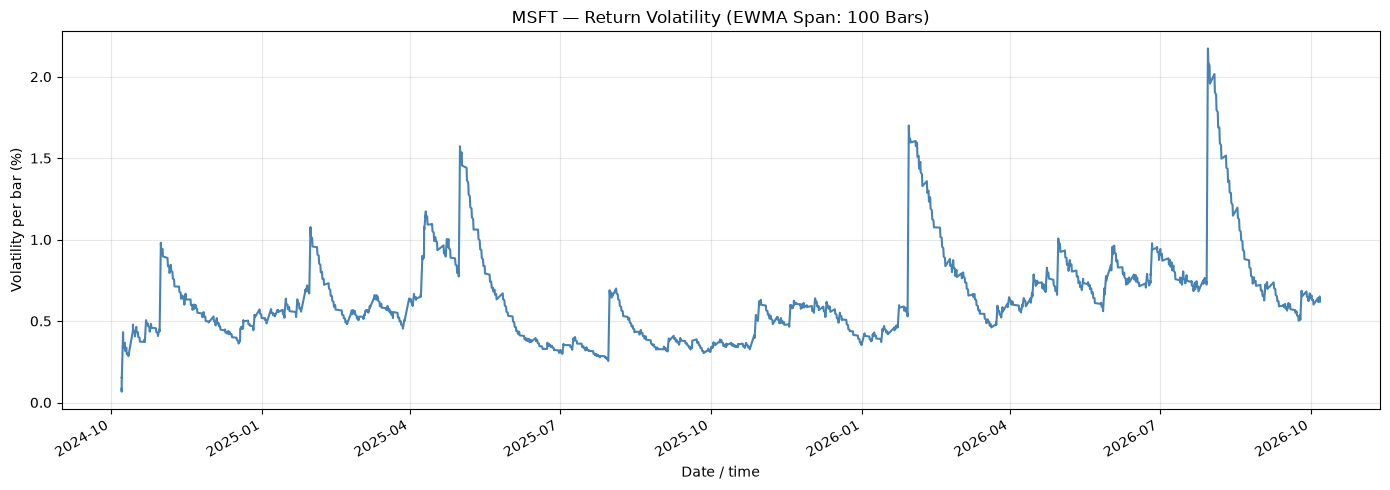

In [17]:
# Volatility is the standard deviation of returns at the input bar frequency.
ax = (msft_volatility * 100).plot(
    figsize=(14, 5),
    legend=False,
    color="steelblue",
    title=f"MSFT — Return Volatility (EWMA Span: {volatility_span} Bars)",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Volatility per bar (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


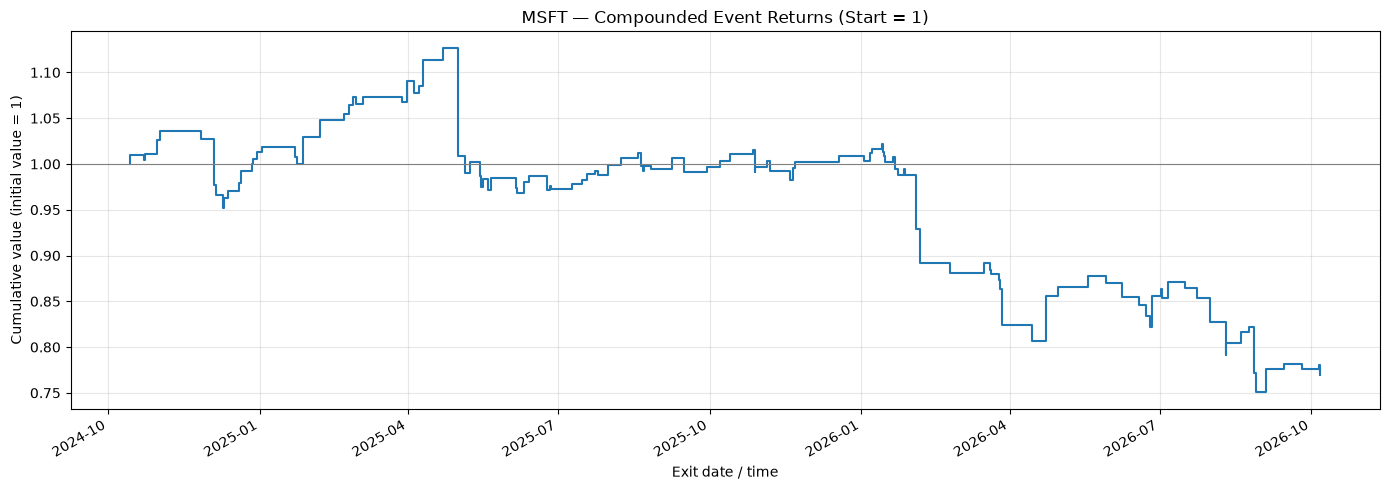

In [18]:
from HelperFunctions.signals import plot_cumulative_returns

# Start at 1 and multiply by (1 + trade return) in exit-time order.
# Overlapping events are retained; this is an event-return summary.
msft_cumulative_returns = plot_cumulative_returns(msft_events, max_workers=32)


## Event Feature Data

Each row in `msft_event_features` describes one event at its signal bar's close and retains the `event_id` index. `msft_event_metadata` holds ticker and signal timestamp separately. All price-based inputs use adjusted prices. Returns below are percentage points unless explicitly described as fractions.

**Timing:** `t` denotes an hourly bar, `P_t` its closing price, and `d` the last trading session strictly before the signal's New York date. Daily inputs never use the current session's eventual close. A trading session is one observed daily price row; weekends and exchange holidays are excluded. Hourly lookbacks count observed bars and can cross overnight gaps. Yahoo's hourly timestamps label the **start** of a bar; its final regular-session bar can be shorter than 60 minutes. The time feature below deliberately describes that start, while the price and volume inputs become available at the bar's close.

| Feature column | Exact calculation and units |
|---|---|
| `volatility_ewma` | Existing `msft_volatility` at the signal bar: standard deviation of 1-bar fractional returns using `ewm(span=100, min_periods=2, adjust=True).std(bias=False)` under the current labeling settings. No annualization. If labeling parameters change, this feature follows them. |
| `volatility_ratio20_100` | EWMA standard deviation with span 20 bars and minimum 20 returns divided by EWMA standard deviation with span 100 bars and minimum 100 returns; both use `adjust=True`, `bias=False`. Unitless. |
| `volume_shares` | Shares traded during the signal bar. |
| `relative_volume20_sessions` | Signal-bar volume divided by the mean volume of the previous 20 observed sessions' bars with the same New York start hour and minute. Current bar excluded; requires 20 prior observations of that slot. Unitless. |
| `above_daily_sma50` | 1 if `P_t` exceeds the mean of 50 completed daily closes ending at `d`; 0 otherwise, including equality. Missing until 50 daily closes exist. |
| `distance_daily_sma50_pct` | `100 * (P_t / SMA50_d - 1)`, using those same 50 completed daily closes. |
| `daily_sma50_slope5_pct` | `100 * (SMA50_d / SMA50_(d-5) - 1)`. Five trading-session change in the daily 50-session SMA; requires 55 daily closes. |
| `return_1_bars_pct` | `100 * (P_t / P_(t-1) - 1)`: return across 1 observed hourly bar. |
| `return_3_bars_pct` | `100 * (P_t / P_(t-3) - 1)`: cumulative return across 3 observed hourly bars. |
| `return_6_bars_pct` | `100 * (P_t / P_(t-6) - 1)`: cumulative return across 6 observed hourly bars. |
| `return_5_daily_sessions_pct` | `100 * (Close_d / Close_(d-5) - 1)`: cumulative stock return across 5 completed trading sessions, excluding the signal's session. |
| `rsi14` | Wilder's 14-bar RSI at the signal bar; range 0–100. |
| `rsi14_change1_bar` | `RSI_t - RSI_(t-1)`, in RSI points. |
| `overnight_gap_pct` | `100 * (current session's first observed hourly Open / previous completed daily Close - 1)`. Missing first-session opening bars can make this a first-observed-bar gap rather than the exchange opening gap. |
| `bar_start_minutes_since0930` | Hourly bar's New York start time minus 09:30, in minutes; e.g. 09:30 = 0, 10:30 = 60, 15:30 = 360. |
| `weekday` | New York trading weekday: Monday = 0, Tuesday = 1, Wednesday = 2, Thursday = 3, Friday = 4. |
| `spy_return_3_daily_sessions_pct` | `100 * (SPY_Close_d / SPY_Close_(d-3) - 1)`: cumulative SPY return across exactly 3 completed trading sessions. This is a compounded endpoint return, not a sum of daily returns. |

Lookback shortages remain missing; no backward filling or automatic event deletion occurs. Bar structure, trade direction, benchmark volatility, and stock-minus-benchmark returns are excluded. Fundamentals are deferred until historical publication-time data are available. `side`, realized return, exit time, and meta-label are not feature columns.


In [19]:
from HelperFunctions.features import event_features

# Extra daily history warms up the 50-session SMA and its 5-session slope.
feature_start = msft_prices.index.min().date() - pd.Timedelta(days=180)
feature_end = msft_prices.index.max().date() + pd.Timedelta(days=1)
msft_daily_features = yf.Ticker("MSFT").history(
    start=feature_start, end=feature_end, interval="1d", auto_adjust=True,
)
spy_daily_features = yf.Ticker("SPY").history(
    start=feature_start, end=feature_end, interval="1d", auto_adjust=True,
)
if msft_daily_features.empty or spy_daily_features.empty:
    raise ValueError("Daily MSFT and SPY data are required for event features.")

msft_event_features, msft_event_metadata = event_features(
    hourly={"MSFT": msft_hourly},
    daily={"MSFT": msft_daily_features},
    spy_daily=spy_daily_features,
    events=msft_events,
    volatility=msft_volatility,
    rsi=msft_rsi,
)
print(f"Feature table: {msft_event_features.shape[0]:,} events, "
      f"{msft_event_features.shape[1]} features")
display(msft_event_features.head())
display(msft_event_features.isna().sum().rename("missing_events").to_frame())


Feature table: 144 events, 17 features


,volatility_ewma,volatility_ratio20_100,volume_shares,relative_volume20_sessions,above_daily_sma50,distance_daily_sma50_pct,daily_sma50_slope5_pct,return_1_bars_pct,return_3_bars_pct,return_6_bars_pct,return_5_daily_sessions_pct,rsi14,rsi14_change1_bar,overnight_gap_pct,bar_start_minutes_since0930,weekday,spy_return_3_daily_sessions_pct
event_id,,,,,,,,,,,,,,,,,
0,0.004395,NaN,3743589.0,NaN,1.0,3.033242,-0.156419,1.730346,2.017003,1.994896,0.062490,70.447830,18.687200,1.923756,0.0,0.0,1.118326
1,0.005051,NaN,7236351.0,NaN,1.0,3.617519,0.431841,2.206151,2.732282,3.411039,-0.085912,75.018120,17.826794,1.633068,0.0,1.0,0.228381
2,0.004947,NaN,1064219.0,NaN,1.0,3.443237,0.431841,0.333391,-0.168197,2.559489,-0.085912,70.061030,2.165832,1.633068,180.0,1.0,0.228381
3,0.004478,1.077396,6001246.0,NaN,1.0,5.652081,0.217173,1.365834,1.265033,1.941656,1.038584,75.559353,11.641937,2.869573,0.0,2.0,0.436785
4,0.004373,1.005388,1845612.0,NaN,1.0,5.544707,0.217173,0.250978,-0.101630,1.162117,1.038584,71.120558,1.976675,2.869573,180.0,2.0,0.436785


,missing_events
volatility_ewma,0
volatility_ratio20_100,3
volume_shares,0
relative_volume20_sessions,6
above_daily_sma50,0
distance_daily_sma50_pct,0
daily_sma50_slope5_pct,0
return_1_bars_pct,0
return_3_bars_pct,0
return_6_bars_pct,0


In [20]:
# Drop an event if ANY of its feature values is missing.
complete_feature_mask = msft_event_features.notna().all(axis=1)
msft_event_features_clean = msft_event_features.loc[complete_feature_mask].copy()
retained_event_ids = msft_event_features_clean.index

# Preserve event IDs and apply the same selection to related tables.
msft_events_clean = msft_events.loc[retained_event_ids].copy()
msft_event_metadata_clean = msft_event_metadata.loc[retained_event_ids].copy()
msft_labels_clean = msft_labels.loc[
    msft_labels.index.isin(retained_event_ids)
].copy()

print(f"Dropped {int((~complete_feature_mask).sum()):,} events with missing features")
print(f"Retained {len(msft_event_features_clean):,} events with all features available")
print(f"Retained {len(msft_labels_clean):,} completed-event labels")
display(msft_event_features_clean.head())


Dropped 6 events with missing features
Retained 138 events with all features available
Retained 138 completed-event labels


,volatility_ewma,volatility_ratio20_100,volume_shares,relative_volume20_sessions,above_daily_sma50,distance_daily_sma50_pct,daily_sma50_slope5_pct,return_1_bars_pct,return_3_bars_pct,return_6_bars_pct,return_5_daily_sessions_pct,rsi14,rsi14_change1_bar,overnight_gap_pct,bar_start_minutes_since0930,weekday,spy_return_3_daily_sessions_pct
event_id,,,,,,,,,,,,,,,,,
6,0.005549,0.957457,6451347.0,1.268351,1.0,2.301869,-0.197521,1.415419,2.009774,1.970586,0.930415,71.408778,10.997712,1.569219,0.0,1.0,1.190533
7,0.005281,1.039236,3899831.0,0.842617,1.0,3.852643,-0.246927,1.492042,2.146117,1.461308,2.564977,70.693902,12.662250,0.917137,0.0,0.0,0.840110
8,0.005181,0.968006,2223879.0,1.335748,1.0,3.935854,-0.246927,0.146178,1.573362,1.895199,2.564977,70.682876,1.004710,0.917137,120.0,0.0,0.840110
9,0.005081,0.899961,1054645.0,0.735271,1.0,4.023894,-0.246927,0.127457,0.231008,1.953789,2.564977,70.918095,0.965384,0.917137,240.0,0.0,0.840110
10,0.005182,1.103211,6605292.0,1.468251,1.0,5.695701,-0.154292,1.618959,1.992736,1.558898,2.963305,76.255757,12.523165,1.779974,0.0,2.0,0.848318


## Sequential Bootstrap: Event Uniqueness

Each matrix row is an **observed hourly candle**, and each column is an event identified by its `event_id`. Use `entry_time` through the actual first-touch end `t1`, inclusive. Candle timestamps are start labels (for example, 09:30); timestamps within that hourly candle map to its label. Only candles covered by events are retained; overnight and weekend candles are never fabricated.

For event $i$, let $B_i$ be its set of covered candles. The indicator matrix, concurrency, and average uniqueness are

$$I_{t,i}=\mathbf{1}\{t\in B_i\},\qquad c_t=\sum_i I_{t,i},$$

$$u_{t,i}=\frac{I_{t,i}}{c_t}\quad(c_t>0),\qquad
\bar u_i=\frac{1}{|B_i|}\sum_{t\in B_i}\frac{1}{c_t}.$$

Inactive candles do not enter an event's average. An isolated event has average uniqueness 1.

Sequential bootstrap samples **events with replacement**. Given the ordered sample $\phi$, its candle concurrency counts every selected copy:

$$c_t^{(\phi)}=\sum_{j\in\phi} I_{t,j}.$$

Temporarily append each candidate $i$, score the appended copy, and normalize:

$$s_i(\phi)=\frac{1}{|B_i|}\sum_{t\in B_i}\frac{1}{c_t^{(\phi)}+1},\qquad
p_i(\phi)=\frac{s_i(\phi)}{\sum_j s_j(\phi)}.$$

Draw one event with probability $p_i(\phi)$, append its ID, and recompute. The first draw is uniform. Repeated IDs remain in draw order. The default number of draws equals the input event count; `sample_length` overrides it and `seed` makes the result reproducible.

`create_events` preserves the observed candle index in DataFrame attributes. Rerun the labeling cell after updating the helpers, or pass `bar_index=msft_prices.index` explicitly. Missing ends (including incomplete/excluded events), reversed times, and endpoints outside observed candles raise errors. The example explicitly selects completed events and reports that selection; no events are silently discarded by the function.

The sampler uses candle-span prefix sums rather than rebuilding matrices on each draw. There is no artificial size cap. Diagnostics optionally construct a sparse indicator matrix and return original event uniqueness, final sampled concurrency, and the selected score and probability at each draw. These are inspection aids, not evidence that every random sample has higher uniqueness.


In [21]:
import importlib
import HelperFunctions.sci_functions as sci_functions

# Refresh helpers already imported earlier in this notebook session.
importlib.reload(sci_functions)

from HelperFunctions.sci_functions import (
    indicator_matrix, average_uniqueness, sequential_bootstrap,
)

# Explicit eligibility selection: incomplete/excluded events have no valid t1.
msft_bootstrap_events = msft_events.loc[msft_events["status"].eq("complete")].copy()
print(f"Bootstrap input: {len(msft_bootstrap_events):,} completed events "
      f"of {len(msft_events):,} total events")
msft_bootstrap_ids, msft_bootstrap_diagnostics = sequential_bootstrap(
    msft_bootstrap_events,
    sample_length=None,  # Defaults to the number of input events.
    seed=42,
    bar_index=msft_prices.index,
    diagnostics=True,
)
print(f"Draws: {len(msft_bootstrap_ids):,}; "
      f"distinct selected events: {len(set(msft_bootstrap_ids)):,}")
display(msft_bootstrap_diagnostics["average_uniqueness"].describe())
display(msft_bootstrap_diagnostics["draws"].head(10))
display(msft_bootstrap_diagnostics["indicator_matrix"].iloc[:10, :10].sparse.to_dense())


Bootstrap input: 144 completed events of 144 total events
Draws: 144; distinct selected events: 105


count    144.000000
mean       0.830306
std        0.212364
min        0.325758
25%        0.666667
50%        1.000000
75%        1.000000
max        1.000000
Name: average_uniqueness, dtype: float64

,draw,event_id,candidate_uniqueness,probability
0,0,111,1.0,0.006944
1,1,62,1.0,0.006969
2,2,123,1.0,0.006993
3,3,99,1.0,0.007029
4,4,13,1.0,0.007061
5,5,140,1.0,0.007122
6,6,108,1.0,0.007147
7,7,113,1.0,0.007186
8,8,18,1.0,0.007218
9,9,64,1.0,0.007271


event_id,0,1,2,3,4,5,6,7,8,9
Datetime,,,,,,,,,,
2024-10-14 09:30:00-04:00,1,0,0,0,0,0,0,0,0,0
2024-10-14 10:30:00-04:00,1,0,0,0,0,0,0,0,0,0
2024-10-22 09:30:00-04:00,0,1,0,0,0,0,0,0,0,0
2024-10-22 10:30:00-04:00,0,1,0,0,0,0,0,0,0,0
2024-10-22 11:30:00-04:00,0,1,0,0,0,0,0,0,0,0
2024-10-22 12:30:00-04:00,0,1,1,0,0,0,0,0,0,0
2024-10-22 13:30:00-04:00,0,1,1,0,0,0,0,0,0,0
2024-10-22 14:30:00-04:00,0,1,0,0,0,0,0,0,0,0
2024-10-22 15:30:00-04:00,0,1,0,0,0,0,0,0,0,0


## Sample Weights: Return Attribution, Time Decay, and Class Balance

Use `msft_events_clean` and its aligned binary meta-labels. Each original event receives one weight, retained under its event ID. Missing labels or incomplete events raise errors rather than being silently removed.

### Return attribution

Compute log returns on the full observed closing-price index **before** restricting to event-covered candles:

$$r_t=\log(P_t/P_{t-1}),\qquad c_t=\sum_i I_{t,i}.$$

The indicator includes entry and exit candles. However, our entry occurs at the signal candle's close, so its incoming return is excluded. Divide subsequent returns by inclusive candle concurrency, sum through the exit candle, and then take the absolute value:

$$R_i=\sum_{t:\,t_{0,i}<t\le t_{1,i}}\frac{r_t}{c_t},\qquad
 a_i=|R_i|,\qquad w_i^{\mathrm{return}}=\frac{N a_i}{\sum_j a_j}.$$

Positive and negative returns can cancel before the absolute value. Larger net attributed moves receive greater weight regardless of profit/loss label or trade direction. Zero attributed returns get zero weight; an all-zero set raises an error. Return weights sum to $N$. The formulas use candle order after mapping endpoints to their observed candle labels.

### Time decay

Inclusive average uniqueness is $\bar u_i=|B_i|^{-1}\sum_{t\in B_i}1/c_t$. Sort events by entry candle, preserving input order for ties, and define

$$x_i=\sum_{j\le i}\bar u_j,\qquad X=\sum_j\bar u_j.$$

For $-1<c\le1$, the decay factor is

$$d_i=\begin{cases}
 c+(1-c)x_i/X,&0\le c\le1,\\
 \max\left(0,\dfrac{c+x_i/X}{1+c}\right),&-1<c<0.
\end{cases}$$

Default `decay=0.5` gives the newest event factor 1 and approaches 0.5 at the oldest boundary. The oldest actual event lies above that boundary because cumulative uniqueness includes the event itself. `decay=1` disables decay; negative values zero the oldest portion of cumulative uniqueness. This clock is cumulative uniqueness, not calendar age.

### Balanced class factors

For each represented label $k$, with count $n_k$ among $N$ input events and $K$ represented classes:

$$q_k=\frac{N}{K n_k}.$$

Default `class_weight="balanced"` increases the factor for rarer labels. `class_weight=None` disables class factors. This balances event counts before return/time weighting; it does not guarantee equal final weight totals per class. For this study, label 0 means losing/flat and label 1 means profitable.

### Combined weight and optional normalization

$$v_i=w_i^{\mathrm{return}}d_iq_{y_i},\qquad
w_i^{\mathrm{final}}=\begin{cases}
 v_i,&\texttt{normalize\_final=False},\\
 \dfrac{N v_i}{\sum_j v_j},&\texttt{normalize\_final=True}.
\end{cases}$$

Final normalization defaults to **off**. Turning it on preserves relative weights and zeros, while rescaling the mean to 1. The supplied AFML excerpts normalize return weights before decay and do not show a final combined normalization. The effect of overall scale on fitting depends on the estimator and its objective/regularization settings; this remains a study topic noted at the top of the notebook.

**Reference:** supplied excerpts from *Advances in Financial Machine Learning*, Chapter 4: §4.6 and Snippet 4.10 (return attribution), §4.7 (time decay), and §4.8 (class weights). Excluding the entry candle's incoming return is our explicit trade-timing convention.

For random forest and gradient boosting, pass `final_weight` through `sample_weight`. Leave the random forest's own `class_weight` unset so balancing is applied once. When introducing train/test splits, recompute weights on each training subset. The full-data example below is for diagnostics, not model validation.


In [23]:
import importlib
import HelperFunctions.sci_functions as sci_functions
importlib.reload(sci_functions)

msft_weight_diagnostics = sci_functions.sample_weights(
    msft_events_clean,
    close=msft_prices,
    labels=msft_labels_clean,
    decay=0.5,
    class_weight="balanced",
    normalize_final=False,  # Toggle to rescale the combined weights to mean 1.
)
msft_sample_weights = msft_weight_diagnostics["final_weight"]
assert msft_sample_weights.index.equals(msft_event_features_clean.index)
display(msft_weight_diagnostics.head(10))
display(msft_weight_diagnostics.describe())
display(msft_weight_diagnostics.groupby("label").agg(
    event_count=("final_weight", "size"),
    total_weight=("final_weight", "sum"),
    mean_weight=("final_weight", "mean"),
))


,label,attributed_return,absolute_attributed_return,average_uniqueness,return_weight,time_factor,class_factor,combined_weight,final_weight
event_id,,,,,,,,,
6,0,0.008423,0.008423,1.000000,0.969438,0.504353,0.971831,0.475166,0.475166
7,0,0.004181,0.004181,0.438889,0.481160,0.506264,0.971831,0.236732,0.236732
8,0,0.004110,0.004110,0.352564,0.473037,0.507799,0.971831,0.233441,0.233441
9,0,0.003899,0.003899,0.325758,0.448746,0.509217,0.971831,0.222072,0.222072
10,0,0.010727,0.010727,0.925000,1.234586,0.513244,0.971831,0.615795,0.615795
11,0,0.002757,0.002757,0.638889,0.317295,0.516025,0.971831,0.159120,0.159120
12,0,0.001884,0.001884,0.458333,0.216839,0.518020,0.971831,0.109163,0.109163
13,1,-0.007172,0.007172,0.757576,0.825406,0.521318,1.029851,0.443144,0.443144
14,1,-0.002472,0.002472,0.500000,0.284459,0.523495,1.029851,0.153358,0.153358


,label,attributed_return,absolute_attributed_return,average_uniqueness,return_weight,time_factor,class_factor,combined_weight,final_weight
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,0.485507,0.000618,0.008689,0.832283,1.000000,0.752727,1.000000,0.770729,0.770729
std,0.501611,0.011327,0.007255,0.212143,0.834986,0.148885,0.029103,0.686548,0.686548
min,0.000000,-0.032749,0.001521,0.325758,0.175052,0.504353,0.971831,0.109163,0.109163
25%,0.000000,-0.006569,0.004570,0.673611,0.525985,0.629259,0.971831,0.370232,0.370232
50%,0.000000,0.002126,0.006854,1.000000,0.788828,0.750418,0.971831,0.564268,0.564268
75%,1.000000,0.006944,0.010948,1.000000,1.260059,0.880446,1.029851,0.910131,0.910131
max,1.000000,0.051770,0.051770,1.000000,5.958280,1.000000,1.029851,4.419517,4.419517


,event_count,total_weight,mean_weight
label,,,
0,71,52.803157,0.743706
1,67,53.557425,0.799365
